# 01. Exploración de Datos (EDA)

En esta etapa, nos enfocaremos en entender la naturaleza del dataset de *California Housing*.
**Objetivo:** Obtener un entendimiento de los datos, de la industria, identificar anomalías, rangos, y relaciones clave.

### Instrucciones Generales:
1. **Carga los datos:** Lee el archivo `.csv` proveniente de la carpeta `data/raw/`
2. **Inspección:** Analisis exploratorio de datos, estructura, problemas de calidad: consistencia, sensibilidad, precision y completitud.
3. **Histogramas:** Genera histogramas para cada variable numérica usando `.hist()`.
4. **Visualización Geoespacial:** Crea un gráfico de dispersión (scatter plot) usando `longitude` y `latitude`. 
   - *Tip:* Utiliza el argumento `alpha=0.2` para ver lugares de alta densidad y `c` para colorear acorde a `median_house_value`.
5. **Correlaciones:** Calcula la matriz de correlación (usando `.corr()`) de todas las variables frente a `median_house_value` para encontrar las más prometedoras y graficos de dispercion entre las variables.
6. **Concluciones**: Redactar todos los hallazgos con un lenguaje de negocio y comunicativo.

In [1]:
# Escribe tu código aquí para explorar el dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("../data/raw/housing/housing.csv")
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dimensiones: 20640 filas x 10 columnas


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df.shape

(20640, 10)

In [4]:
#Inspección y calidad de datos

print("=== ESTRUCTURA ===")
df.info()

print("\n=== VALORES NULOS ===")
print(df.isnull().sum())

print("\n=== ESTADÍSTICAS ===")
df.describe()

=== ESTRUCTURA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB

=== VALORES NULOS ===
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
m

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [5]:
# Contar filas duplicadas
duplicados = df.duplicated().sum()
print(f"Total filas duplicadas: {duplicados}")
print(f"Porcentaje: {duplicados/len(df)*100:.2f}%")

Total filas duplicadas: 0
Porcentaje: 0.00%


In [6]:
print("=== COMPLETITUD ===")
print(f"Total filas: {len(df)}")
print(f"\nValores nulos por columna:")
nulos = df.isnull().sum()
porcentaje = (df.isnull().sum() / len(df) * 100).round(2)
completitud = pd.DataFrame({
    "Nulos": nulos,
    "Porcentaje %": porcentaje,
    "Completos %": (100 - porcentaje).round(2)
})
print(completitud)

=== COMPLETITUD ===
Total filas: 20640

Valores nulos por columna:
                    Nulos  Porcentaje %  Completos %
longitude               0           0.0        100.0
latitude                0           0.0        100.0
housing_median_age      0           0.0        100.0
total_rooms             0           0.0        100.0
total_bedrooms        207           1.0         99.0
population              0           0.0        100.0
households              0           0.0        100.0
median_income           0           0.0        100.0
median_house_value      0           0.0        100.0
ocean_proximity         0           0.0        100.0


In [7]:
print("=== PRECISIÓN ===")

# Verificar valores negativos o cero en columnas que no deberían tenerlos
cols_positivas = ["total_rooms", "total_bedrooms", "population", 
                  "households", "median_income", "median_house_value"]

for col in cols_positivas:
    negativos = (df[col] <= 0).sum()
    print(f"{col}: {negativos} valores <= 0")

# Detectar outliers con IQR
print("\n--- Outliers por IQR ---")
for col in cols_positivas:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5*IQR) | 
                (df[col] > Q3 + 1.5*IQR)).sum()
    print(f"{col}: {outliers} outliers ({outliers/len(df)*100:.2f}%)")

=== PRECISIÓN ===
total_rooms: 0 valores <= 0
total_bedrooms: 0 valores <= 0
population: 0 valores <= 0
households: 0 valores <= 0
median_income: 0 valores <= 0
median_house_value: 0 valores <= 0

--- Outliers por IQR ---
total_rooms: 1287 outliers (6.24%)
total_bedrooms: 1271 outliers (6.16%)
population: 1196 outliers (5.79%)
households: 1220 outliers (5.91%)
median_income: 681 outliers (3.30%)
median_house_value: 1071 outliers (5.19%)


In [8]:
print("=== SENSIBILIDAD ===")

# Revisar si hay columnas con datos personales
cols_sensibles = ["nombre", "email", "telefono", 
                  "cedula", "direccion"]

sensibles_encontradas = [col for col in cols_sensibles 
                         if col in df.columns]

if len(sensibles_encontradas) == 0:
    print("✅ No se encontraron columnas con datos personales")
    print("✅ El dataset es anónimo y seguro de usar")
else:
    print(f"⚠️ Columnas sensibles encontradas: {sensibles_encontradas}")

# Revisar columnas de ubicación
print("\nColumnas de ubicación presentes:")
print("→ longitude y latitude identifican zonas geográficas")
print("→ No identifican personas directamente")
print("→ Nivel de sensibilidad: BAJO ✅")

=== SENSIBILIDAD ===
✅ No se encontraron columnas con datos personales
✅ El dataset es anónimo y seguro de usar

Columnas de ubicación presentes:
→ longitude y latitude identifican zonas geográficas
→ No identifican personas directamente
→ Nivel de sensibilidad: BAJO ✅


In [9]:
print("=== CONSISTENCIA ===")

# Regla 1: total_bedrooms no puede ser mayor que total_rooms
inconsistencia1 = (df["total_bedrooms"] > df["total_rooms"]).sum()
print(f"total_bedrooms > total_rooms: {inconsistencia1} casos")

# Regla 2: population no puede ser menor que households
inconsistencia2 = (df["population"] < df["households"]).sum()
print(f"population < households: {inconsistencia2} casos")

# Regla 3: households no puede ser mayor que population
inconsistencia3 = (df["households"] > df["population"]).sum()
print(f"households > population: {inconsistencia3} casos")

# Regla 4: rooms_per_household debe ser >= 1
df_temp = df.copy()
df_temp["rooms_per_household"] = df["total_rooms"] / df["households"]
inconsistencia4 = (df_temp["rooms_per_household"] < 1).sum()
print(f"rooms_per_household < 1: {inconsistencia4} casos")

# Resumen
total_inconsistencias = (inconsistencia1 + inconsistencia2 + 
                         inconsistencia3 + inconsistencia4)
if total_inconsistencias == 0:
    print("\n✅ No se encontraron inconsistencias lógicas")
else:
    print(f"\n⚠️ Total inconsistencias: {total_inconsistencias}")

=== CONSISTENCIA ===
total_bedrooms > total_rooms: 0 casos
population < households: 3 casos
households > population: 3 casos
rooms_per_household < 1: 2 casos

⚠️ Total inconsistencias: 8


In [10]:
# Ver los 3 casos de population < households
print("=== population < households ===")
print(df[df["population"] < df["households"]]
      [["longitude", "latitude", "population", 
        "households", "median_house_value"]])

# Ver los 2 casos de rooms_per_household < 1
print("\n=== rooms_per_household < 1 ===")
df["rooms_per_household"] = df["total_rooms"] / df["households"]
print(df[df["rooms_per_household"] < 1]
      [["total_rooms", "households", 
        "rooms_per_household", "median_house_value"]])

=== population < households ===
      longitude  latitude  population  households  median_house_value
1235    -118.44     34.04         3.0         4.0            350000.0
5892    -121.00     39.75        27.0        39.0             83000.0
5901    -121.00     37.65       198.0       204.0            187500.0

=== rooms_per_household < 1 ===
       total_rooms  households  rooms_per_household  median_house_value
9812          32.0        36.0             0.888889            112500.0
19057         11.0        13.0             0.846154            162500.0


In [13]:
import pandas as pd

# Cargar datos
df = pd.read_csv("../data/raw/housing/housing.csv")

# Filtrar filas con nulos
filas_nulas = df[df["total_bedrooms"].isnull()]
print(f"Total filas con nulos: {len(filas_nulas)}")

# Guardar en CSV
filas_nulas.to_csv("../data/interim/filas_nulas.csv", index=True)
print("✅ Guardado en data/interim/filas_nulas.csv")

Total filas con nulos: 207
✅ Guardado en data/interim/filas_nulas.csv


In [ ]:
#identificar donde están los nulos

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/housing/housing.csv")

# Crear columna indicadora de nulos
df["bedrooms_missing"] = df["total_bedrooms"].isnull().astype(int)

print(f"Total nulos: {df['bedrooms_missing'].sum()}")
print(f"Porcentaje: {df['bedrooms_missing'].mean()*100:.2f}%")

Total nulos: 207
Porcentaje: 1.00%


In [6]:
#Comprobar MCAR
# Si es MCAR los nulos deben estar distribuidos aleatoriamente
# Sin diferencia significativa entre grupos

from scipy import stats

# Dividir en dos grupos: con nulos y sin nulos
grupo_con_nulos    = df[df["bedrooms_missing"] == 1]
grupo_sin_nulos    = df[df["bedrooms_missing"] == 0]

# Comparar medias de otras variables
variables = ["median_income", "total_rooms", "population", "households"]

print("=== PRUEBA MCAR ===")
print(f"{'Variable':<25} {'Media CON nulos':>15} {'Media SIN nulos':>15} {'p-value':>10}")
print("-" * 70)

for var in variables:
    t_stat, p_value = stats.ttest_ind(
        grupo_con_nulos[var].dropna(),
        grupo_sin_nulos[var].dropna()
    )
    significativo = "⚠️ Diferente" if p_value < 0.05 else "✅ Similar"
    print(f"{var:<25} {grupo_con_nulos[var].mean():>15.2f} {grupo_sin_nulos[var].mean():>15.2f} {p_value:>10.4f} {significativo}")

=== PRUEBA MCAR ===
Variable                  Media CON nulos Media SIN nulos    p-value
----------------------------------------------------------------------
median_income                        3.82            3.87     0.7124 ✅ Similar
total_rooms                       2562.60         2636.50     0.6277 ✅ Similar
population                        1477.77         1424.95     0.5043 ✅ Similar
households                         510.02          499.43     0.6917 ✅ Similar


=== PRUEBA MAR ===
Porcentaje de nulos por ocean_proximity:
ocean_proximity
<1H OCEAN     1.116462
INLAND        0.839566
ISLAND        0.000000
NEAR BAY      0.873362
NEAR OCEAN    1.128668
Name: bedrooms_missing, dtype: float64


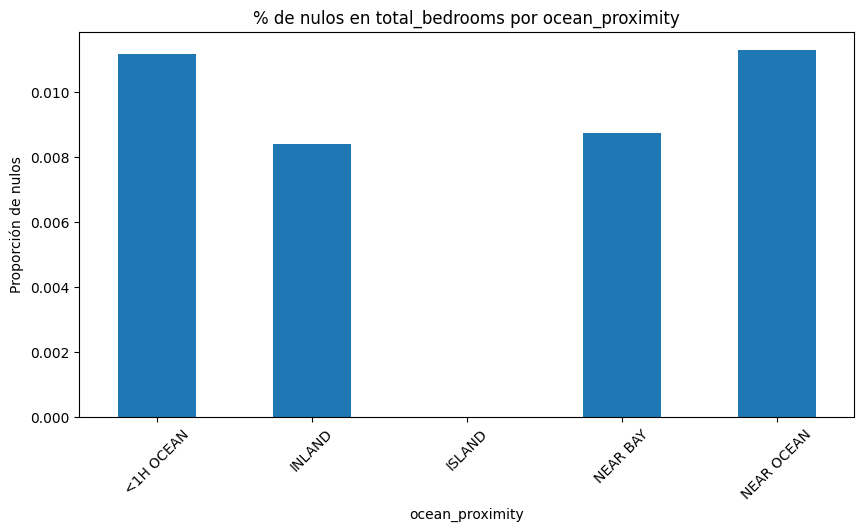

In [7]:
#Comprobar MAR
# Si es MAR los nulos se concentran en categorías específicas
print("=== PRUEBA MAR ===")
print("Porcentaje de nulos por ocean_proximity:")
print(df.groupby("ocean_proximity")["bedrooms_missing"].mean() * 100)

# Visualización
plt.figure(figsize=(10, 5))
df.groupby("ocean_proximity")["bedrooms_missing"].mean().plot(kind="bar")
plt.title("% de nulos en total_bedrooms por ocean_proximity")
plt.ylabel("Proporción de nulos")
plt.xticks(rotation=45)
plt.show()

=== PRUEBA MNAR ===
Estadísticas de total_rooms donde total_bedrooms es nulo:
count      207.000000
mean      2562.603865
std       1787.269789
min        154.000000
25%       1307.500000
50%       2155.000000
75%       3465.000000
max      11709.000000
Name: total_rooms, dtype: float64

Estadísticas de total_rooms donde total_bedrooms NO es nulo:
count    20433.000000
mean      2636.504233
std       2185.269567
min          2.000000
25%       1450.000000
50%       2127.000000
75%       3143.000000
max      39320.000000
Name: total_rooms, dtype: float64


<Figure size 1000x500 with 0 Axes>

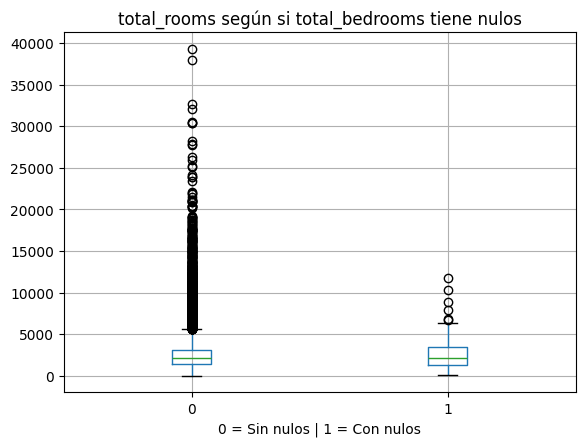

In [8]:
#Comprobar MNAR
# Si es MNAR los nulos ocurren en valores extremos de la misma variable
# Como total_bedrooms tiene nulos, usamos total_rooms como proxy

print("=== PRUEBA MNAR ===")
print("Estadísticas de total_rooms donde total_bedrooms es nulo:")
print(df[df["bedrooms_missing"]==1]["total_rooms"].describe())

print("\nEstadísticas de total_rooms donde total_bedrooms NO es nulo:")
print(df[df["bedrooms_missing"]==0]["total_rooms"].describe())

# Visualización
plt.figure(figsize=(10,5))
df.boxplot(column="total_rooms", by="bedrooms_missing")
plt.title("total_rooms según si total_bedrooms tiene nulos")
plt.suptitle("")
plt.xlabel("0 = Sin nulos | 1 = Con nulos")
plt.show()

Veredicto final: MCAR ✅
→ Los nulos son completamente aleatorios
→ Imputación con mediana es válida y suficiente

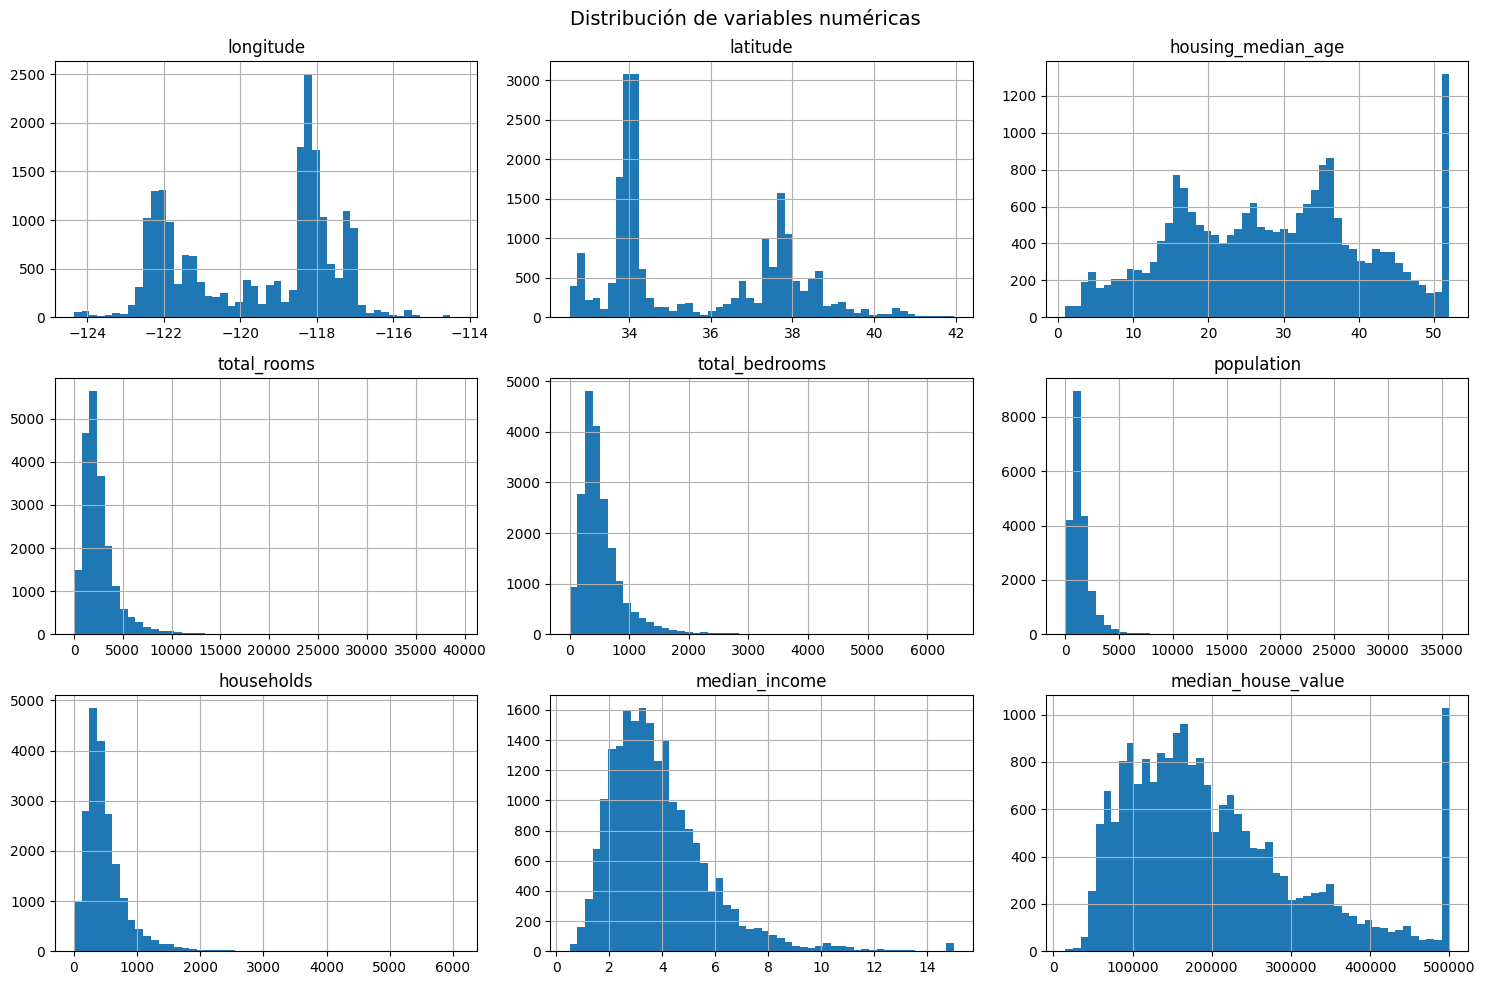

In [15]:
#Histogramas

df.hist(bins=50, figsize=(15, 10))
plt.suptitle("Distribución de variables numéricas", fontsize=14)
plt.tight_layout()
plt.show()

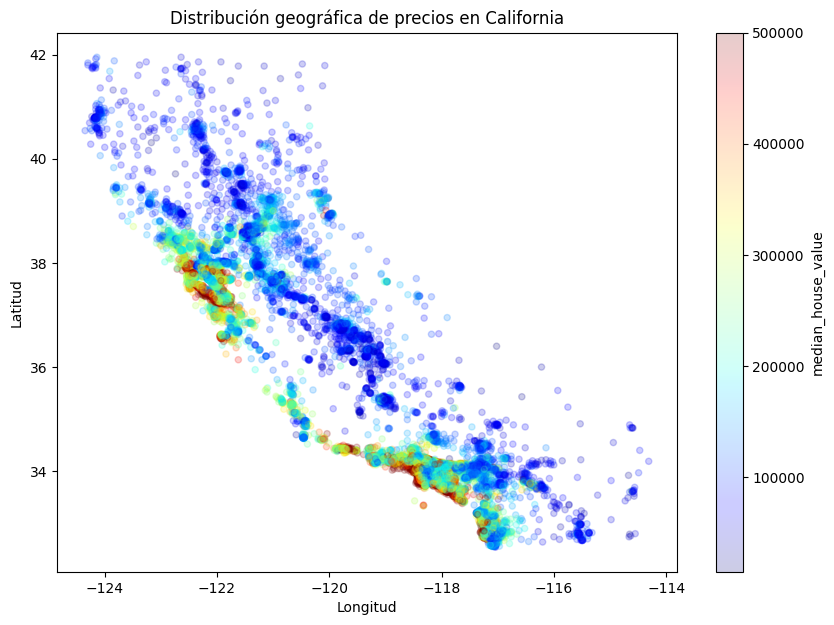

In [16]:
#Visualización Geoespacial

df.plot(kind="scatter", x="longitude", y="latitude",
        alpha=0.2, c="median_house_value",
        cmap="jet", colorbar=True, figsize=(10, 7))
plt.title("Distribución geográfica de precios en California")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.show()

=== CORRELACIONES CON median_house_value ===
median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


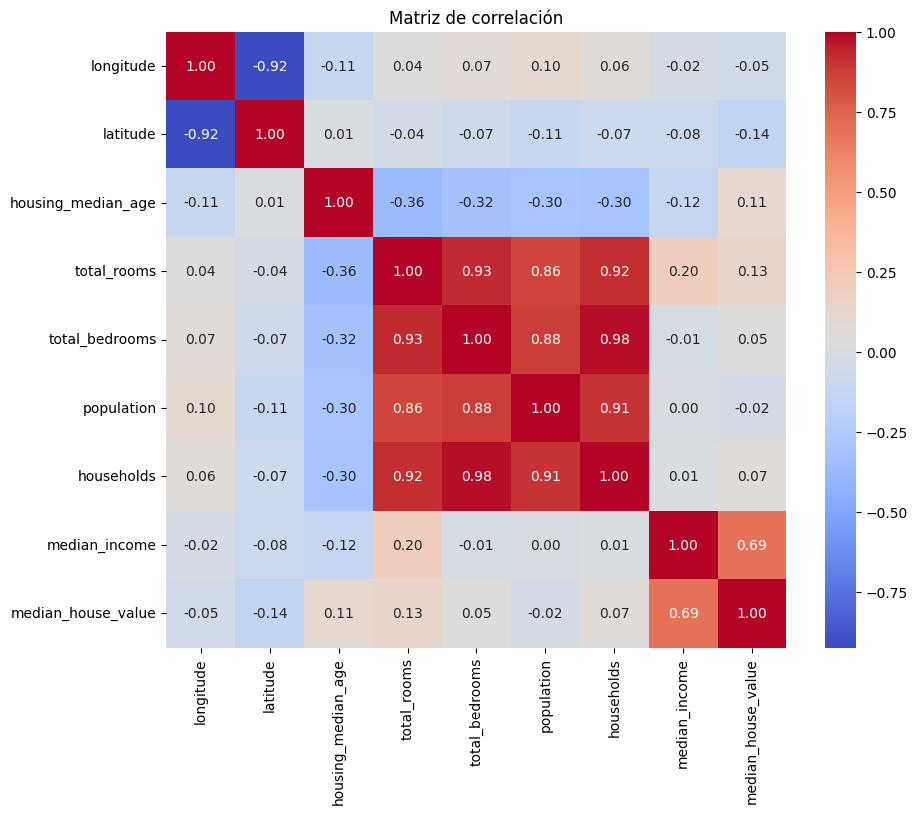

In [17]:
# Matriz de correlación
correlaciones = df.corr(numeric_only=True)["median_house_value"].sort_values(ascending=False)
print("=== CORRELACIONES CON median_house_value ===")
print(correlaciones)

# Gráfico de calor
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

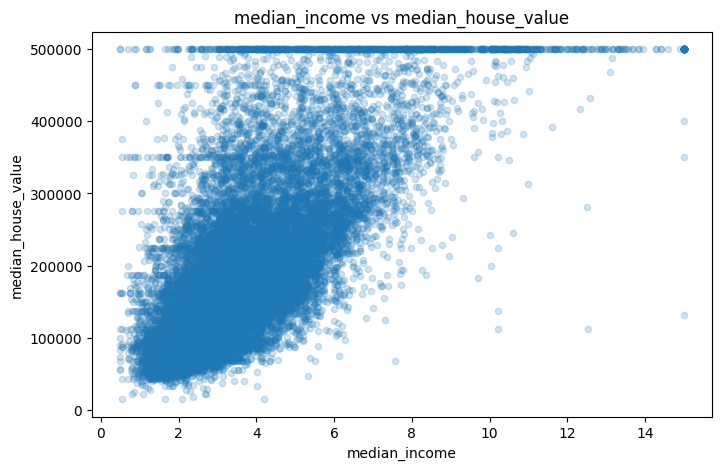

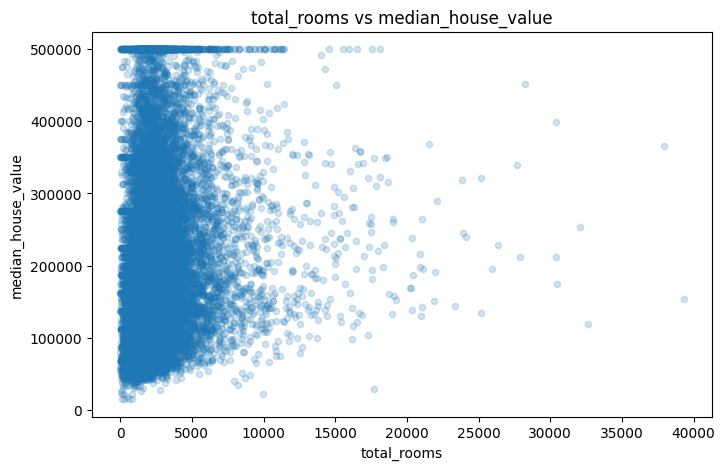

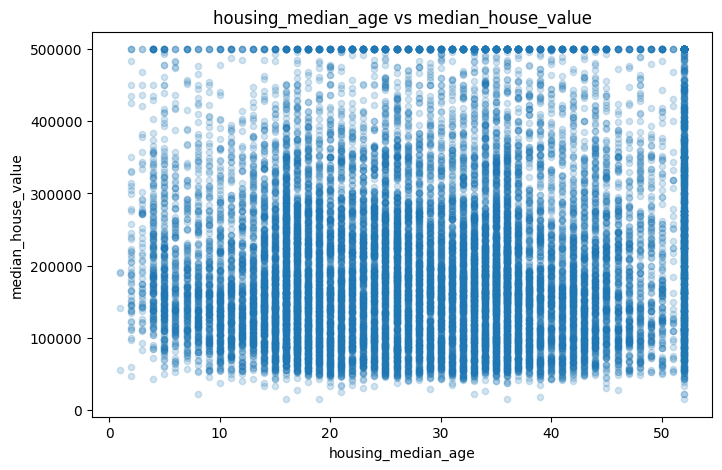

In [18]:
#Gráficos de dispersión variables clave
variables_clave = ["median_income", "total_rooms", "housing_median_age"]

for var in variables_clave:
    df.plot(kind="scatter", x=var, y="median_house_value", alpha=0.2, figsize=(8, 5))
    plt.title(f"{var} vs median_house_value")
    plt.show()

Conclusiones

1. **Calidad de datos:** La variable `total_bedrooms` presenta valores nulos (~207 registros) que deberán ser imputados en la fase de limpieza.

2. **Distribuciones:** Variables como `median_house_value` y `median_income` muestran colas largas hacia la derecha, lo que indica presencia de outliers en propiedades de alto valor.

3. **Geografía:** Las viviendas de mayor precio se concentran en la costa (San Francisco, Los Ángeles), lo que confirma que la ubicación es un factor determinante en el precio.

4. **Correlaciones clave:** 
   - `median_income` tiene la correlación más alta con el precio (≈0.69), siendo el predictor más prometedor.
   - `total_rooms` y `housing_median_age` tienen correlación moderada.

5. **Oportunidades de feature engineering:** Combinar variables como `total_rooms/households` podría capturar mejor el tamaño real por hogar.